<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Standford-dogs-CNN-project-/blob/main/4_regularization_experiments_ipynb_i.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4 — Regularization Experiments

Notebook 3 found the best architecture: 4 conv layers, GAP,
32→64→128→256 filters, no BatchNorm -->achieving 10.25% val accuracy.

The model is still not generalizing well enough. This notebook
asks: can regularization techniques reduce overfitting without
hurting accuracy?

Three techniques tested in isolation:

| Experiment | What changes | Question |
|---|---|---|
| E | Dropout: 0.2 vs 0.3 vs 0.5 | How much is too much? |
| F | L2: none vs 1e-4 vs 1e-3 | Does penalizing weights help? |
| G | Augmentation: none vs basic vs strong | Does fake data help? |

All experiments use:
- 4 conv layers, GAP, 32→64→128→256 filters
- 128×128 input, batch size 32, seed 42
- No BatchNorm

**Baseline to beat: 10.25% val accuracy**

In [ ]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,GlobalAveragePooling2D,Dense, Dropout

from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import pandas as pd
import time
import kagglehub

path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")


Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.


In [ ]:
def load_data(aug=False,img_size=128,batch_size=32):
  def norm(image,label):
    return tf.cast(image/255.,tf.float32),label

  def aug_fn(image,label):
    image =tf.image.random_flip_left_right(image)
    image =tf.image.rnadom_brightness(image,0.2)
    image =tf.image.random_contrast(image,0.8,1.2)
    return image ,label

  train = keras.utils.image_dataset_from_directory(
        path + "/images/Images",
        labels='inferred',
        label_mode='int',
        batch_size=batch_size,
        image_size=(img_size, img_size),
        validation_split=0.2,
        subset='training',
        seed=42
    ).map(norm)

  if aug:
        train = train.map(aug_fn)

  train = train.prefetch(tf.data.AUTOTUNE)

  val = keras.utils.image_dataset_from_directory(
        path + "/images/Images",
        labels='inferred',
        label_mode='int',
        batch_size=batch_size,
        image_size=(img_size, img_size),
        validation_split=0.2,
        subset='validation',
        seed=42
  ).map(norm).prefetch(tf.data.AUTOTUNE)

  return train, val

train_data, val_data = load_data()




Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [ ]:
def build_model(dropout=0.0,l2_strength=0.0):

  reg = l2(l2_strength) if l2_strength > 0 else None

  model = Sequential([
      keras.Input(shape=(128,128,3)),

        # block 1 — params: (3×3×3+1)×32 = 896

        Conv2D(32, (3,3), padding='valid', activation='relu',
               kernel_regularizer=reg),
        MaxPooling2D((2,2)),


        # block 2 — params: (3×3×32+1)×64 = 18,496
        Conv2D(64, (3,3), padding='valid', activation='relu',
               kernel_regularizer=reg),
        MaxPooling2D((2,2)),


        # block 3 — params: (3×3×64+1)×128 = 73,856
        Conv2D(128, (3,3), padding='valid', activation='relu',
               kernel_regularizer=reg),
        MaxPooling2D((2,2)),


        # block 4 — params: (3×3×128+1)×256 = 295,168
        Conv2D(256, (3,3), padding='valid', activation='relu',
               kernel_regularizer=reg),
        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),
        Dense(128, activation='relu', kernel_regularizer=reg),

        Dropout(dropout) if dropout > 0 else tf.keras.layers.Lambda(lambda x: x),

        Dense(120, activation='softmax')
  ])

  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  return model


def train_model(model, train_d=None, epochs=10):
  if train_d is None:
    train_d = train_data
  start = time.time()
  history = model.fit(
      train_d,
      validation_data=val_data,
      epochs=epochs,
      verbose=1
  )
  time_taken = round((time.time()-start)/60, 1)
  val_acc = max(history.history['val_accuracy'])
  print(f"val acc: {val_acc:.2%} | time: {time_taken} mins")
  return history, val_acc, time_taken

In [ ]:
def plot_comparison(histories, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    colors = ['royalblue','tomato','seagreen','orange']
    for i, (history, label) in enumerate(zip(histories, labels)):
        axes[0].plot(history.history['accuracy'],
                     color=colors[i], label=f'{label} train')
        axes[0].plot(history.history['val_accuracy'],
                     color=colors[i], label=f'{label} val',
                     linestyle='--')
        axes[1].plot(history.history['loss'],
                     color=colors[i], label=f'{label} train')
        axes[1].plot(history.history['val_loss'],
                     color=colors[i], label=f'{label} val',
                     linestyle='--')
    axes[0].set_title('Accuracy')
    axes[1].set_title('Loss')
    for ax in axes:
        ax.legend(fontsize=7)
        ax.set_xlabel('Epoch')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## **Experiment E — Dropout: 0.0 vs 0.2 vs 0.3 vs 0.5**

**Hypothesis:** dropout will reduce overfitting by preventing
the model from relying on specific neurons.

However too high
a rate will cause underfitting as too much information gets
dropped during training.

In [ ]:
dropout_history ={}
dropout_acc ={}

for i in [0.0,0.2,0.3,0.5]:
  tf.keras.backend.clear_session()
  print(f"Training dropout={i}")
  model =build_model(dropout=i)
  h,acc,t =train_model(model)
  dropout_history[i]=h
  dropout_acc[i]=acc


Training dropout=0.0
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 73s 129ms/step - accuracy: 0.0148 - loss: 4.7232 - val_accuracy: 0.0153 - val_loss: 4.6741
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.0188 - loss: 4.6300 - val_accuracy: 0.0224 - val_loss: 4.6619
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.0272 - loss: 4.5443 - val_accuracy: 0.0277 - val_loss: 4.5078
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.0338 - loss: 4.4177 - val_accuracy: 0.0350 - val_loss: 4.4431
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.0437 - loss: 4.3084 - val_accuracy: 0.0457 - val_loss: 4.3050
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 51s 76ms/step - accuracy: 0.0565 - loss: 4.1953 - val_accuracy: 0.0595 - val_loss: 4.1849
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.0728 - loss: 4.0439 - val_accuracy: 0.0719 - val_loss: 4.0932
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.

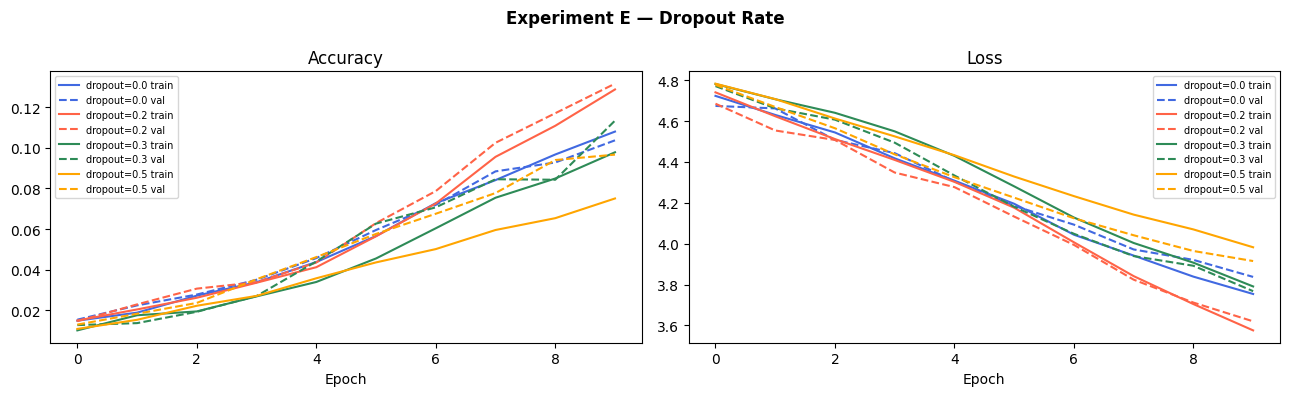

In [ ]:
plot_comparison(
    list(dropout_history.values()),
    [f'dropout={i}' for i in dropout_history.keys()],
    'Experiment E — Dropout Rate'
)

## Experiment E — Results

| Dropout | Val Accuracy | Train Accuracy | Overfitting gap |
|---|---|---|---|
| 0.0 | 10.37% | 10.81% | minimal |
| 0.2 | 13.17% | 12.88% | none — val > train |
| 0.3 | 11.35% | 9.78% | none |
| 0.5 | 9.67% | 7.51% | none — underfitting |

###**Hypothesis: confirmed**

## What I observed------------------>

Dropout=0.2 is the clear winner at 13.17% a 27% improvement
over no dropout.

Interesting pattern — val accuracy is actually higher than
train accuracy for dropout=0.2 and 0.3. This happens because
dropout is active during training (randomly dropping neurons)
but disabled during validation. So the validation run uses
the full network while training uses a reduced one.

Dropout=0.5 starts underfitting — train accuracy drops to
7.5% as too many neurons get dropped each step, preventing
the model from learning effectively.

## What this tells us----------------->

A small amount of dropout (0.2) acts as a useful regularizer
without hurting learning. Beyond 0.3 the cost outweighs
the benefit on this dataset.

---------------------------------------------------------------------------
## **Decision: use dropout=0.2 going forward**

**Current best: 13.17% val accuracy**

*Note: val accuracy being higher than train accuracy is
expected with dropout .dropout is disabled during
validation so the full network runs. This is standard
behaviour, not a data leakage issue.*

##**Experiment F — L2 Regularization: none vs 1e-4 vs 1e-3**

**Hypothesis:** L2 will penalize large weights and reduce
overfitting. Too strong a penalty will hurt accuracy by
preventing the model from learning meaningful features.

In [ ]:
l2_history ={}
l2_acc ={}

for strength in [0.0,1e-4,1e-3]:
  tf.keras.backend.clear_session()
  print(f"Training l2={strength}")
  model=build_model(l2_strength=strength)
  h,acc,t =train_model(model)
  l2_history[strength] =h
  l2_acc[strength] =acc


Training l2=0.0
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 60s 102ms/step - accuracy: 0.0137 - loss: 4.7297 - val_accuracy: 0.0138 - val_loss: 4.6971
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.0176 - loss: 4.6334 - val_accuracy: 0.0228 - val_loss: 4.6682
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.0261 - loss: 4.5413 - val_accuracy: 0.0270 - val_loss: 4.5101
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.0330 - loss: 4.4276 - val_accuracy: 0.0350 - val_loss: 4.4070
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.0447 - loss: 4.3144 - val_accuracy: 0.0386 - val_loss: 4.3335
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.0570 - loss: 4.1945 - val_accuracy: 0.0539 - val_loss: 4.2088
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.0727 - loss: 4.0392 - val_accuracy: 0.0671 - val_loss: 4.0847
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0881 

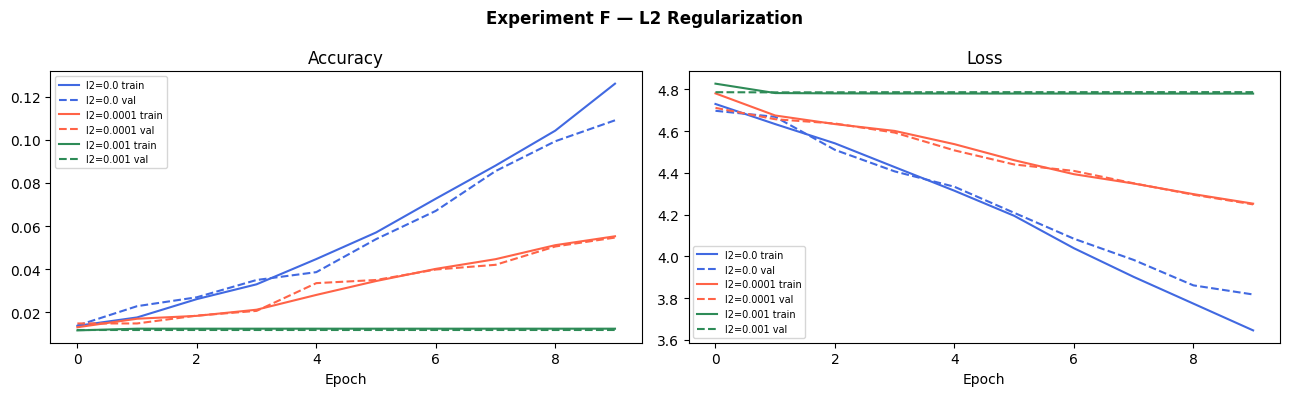

In [ ]:
plot_comparison(
    list(l2_history.values()),
    [f'l2={s}' for s in l2_history.keys()],
    'Experiment F — L2 Regularization'
)

## **Experiment F — Resu**lts

| L2 Strength | Val Accuracy | Train Accuracy | Status |
|---|---|---|---|
| none (0.0) | 10.91% | 12.61% | learning |
| 1e-4 | 5.47% | 5.53% | slow learning |
| 1e-3 | 1.17% | 1.24% | dead / not learning |

**Hypothesis: partially rejected**

## What I observed---------------------->

No L2 performs best at 10.91%.

L2=1e-4 slows learning significantly — val accuracy drops
to 5.47%. The penalty is discouraging large weights but
also making it harder to learn anything useful.

L2=1e-3 kills learning completely — loss stuck at 4.78
all 10 epochs. Same dead model pattern seen in experiment
A (BatchNorm) and experiment D (large filters).

## This is the third time we've seen this pattern

| Experiment | What killed learning | Loss stuck at |
|---|---|---|
| A | BatchNorm | 4.78 |
| D | 64→128→256→512 filters | 4.78 |
| F | L2=1e-3 | 4.78 |

All three hit log(120) = 4.79 —>random guessing.
The common thread: too much constraint on a small dataset.
BatchNorm constrains activations, large filters overwhelm
capacity, strong L2 constrains weights —> all prevent the
optimizer from finding any useful direction.

## What this tells us--------------------->

L2 regularization does not help this model on this dataset.
Dropout (experiment E) was a better regularizer it
improved accuracy while L2 hurt it.

-------------------------------
##**Decision: no L2 regularization going forward**

**Current best: 13.17% val accuracy (dropout=0.2)**

## **Experiment G — Data Augmentation: none vs basic vs strong**


**Hypothesis:** augmentation will improve val accuracy by
artificially increasing dataset variety, making the model
more robust to unseen images. Strong augmentation may hurt
if transformations make images unrealistic or unrecognizable.

In [ ]:
train_none,_=load_data(aug=False)

#basic -flip only

def basic_aug(image,label):
  image =tf.image.random_flip_left_right(image)
  return image,label

train_basic,_ =load_data(aug=False)
train_basic = train_basic.map(basic_aug).prefetch(tf.data.AUTOTUNE)

#strong - flip + brigtness + contrast + rotation

def strong_aug(image,label):
  image = tf.image.random_flip_left_right(image)
  image = tf.image.random_brightness(image, 0.3)
  image = tf.image.random_contrast(image, 0.7, 1.3)
  image = tf.image.random_saturation(image, 0.7, 1.3)
  return image, label

train_strong,_ =load_data(aug=False)
train_strong =train_strong.map(strong_aug).prefetch(tf.data.AUTOTUNE)

aug_history ={}
aug_acc ={}

for name,train_d in [('none', train_none), ('basic', train_basic),('strong', train_strong)]:
  tf.keras.backend.clear_session()
  print(f"Training augmentation={name}")
  model=build_model()
  h,acc,t =train_model(model,train_d=train_d)
  aug_history[name]=h
  aug_acc[name]=acc



Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Training augmentation=none
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 87s 157ms/step - accuracy: 0.0146 - loss: 4.7416 - val_accuracy: 0.0143 - val_loss: 4.7166
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0196 - loss: 4.6156 - val_accuracy: 0.0258 - val_loss: 4.5974
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.0316 - loss: 4.4636 - val_accuracy: 0.0335 - val_loss: 4.4453
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.0414 - loss: 4.3115 - val_accuracy: 0.0517 - val_loss: 

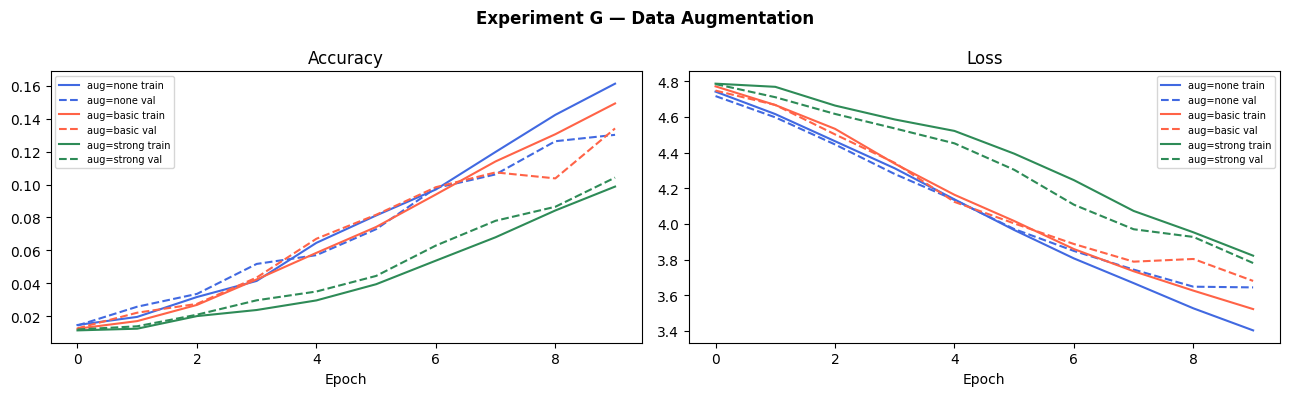

In [ ]:
plot_comparison(
    list(aug_history.values()),
    [f'aug={n}' for n in aug_history.keys()],
    'Experiment G — Data Augmentation'
)

## **Experiment G — Results**

| Augmentation | Val Accuracy | Train Accuracy | Gap |
|---|---|---|---|
| None | 13.02% | 16.13% | 3.1% — slight overfit |
| Basic (flip only) | 13.41% | 14.93% | 1.5% — minimal overfit |
| Strong (flip+brightness+contrast+saturation) | 10.42% | 9.88% | minimal — but underfit |

**Hypothesis: partially confirmed**

## What I observed------------------->

Basic augmentation wins narrowly at 13.41% marginal
improvement over no augmentation (13.02%).

The chart shows something important — no augmentation
has the biggest train val gap (blue train line pulls
away from blue val). Basic augmentation keeps them
closer together. This confirms augmentation reduces
overfitting even when accuracy numbers look similar.

Strong augmentation hurts — 10.42% val accuracy,
train accuracy also low at 9.88%. Too many simultaneous
transformations make images hard to learn from.
Brightness + contrast + saturation changes together
alter the image too aggressively for only 10 epochs.

## Why augmentation didn't help as much as expected--->

Two likely reasons:
1. Only 10 epochs — augmentation benefits compound
   over more epochs. The model hasn't seen enough
   augmented variations yet to benefit fully
2. The model is still relatively weak — augmentation
   helps more when the model has enough capacity to
   learn from the variety

This suggests augmentation will become more valuable
in later notebooks when combined with better
regularization and more epochs.


## Notebook 4 — All Results

| Experiment | Model | Val Accuracy | Key Finding |
|---|---|---|---|
| E | dropout=0.0 | 10.37% | reference |
| E | dropout=0.2 | 13.17% | best dropout |
| E | dropout=0.3 | 11.35% | good but not best |
| E | dropout=0.5 | 9.67% | underfitting |
| F | L2=none | 10.91% | reference |
| F | L2=1e-4 | 5.47% | hurt learning |
| F | L2=1e-3 | 1.17% | dead model |
| G | no augmentation | 13.02% | reference |
| G | basic augmentation | 13.41% | best aug |
| G | strong augmentation | 10.42% | too aggressive |

**Best config from nb4: dropout=0.2, no L2, basic augmentation**
###**Current best: 13.41% val accuracy**
---------------------------------------------------------------------------

##**Decision: basic data augumentation going forward**

####**Moving to notebook 5 —> manual hyperparameter tuning**

*Note: all experiments use 10 epochs for consistency.
Augmentation in particular would likely show stronger
results with more epochs , this is revisited in
notebook 7 with transfer learning.*
